# Plotting Time Series Models

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [29]:
# set folder with data
path = '../results/'
# get all files in the folder
all_files = glob.glob(path + "*.csv")

In [30]:
# filter the files that contain "covid"
covid_files = [f for f in all_files if 'covid' in f]
# filter the files that contain "epidemics"
epidemics_files = [f for f in all_files if 'epidemics' in f]

In [31]:
# get the original data
df_covid = pd.read_csv('../Data/silver/covid_data_weekly.csv')  

In [32]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


In [33]:
nrow_dict = {}
for country in df_covid['country'].unique():
    df_temp = df_covid[df_covid['country'] == country]
    nrow_dict[country] = len(df_temp)

In [34]:
nrow_dict

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [35]:
from functools import reduce

# -------------------------------------------------------------------
# 1.  Load raw CSVs
# -------------------------------------------------------------------
df_dengue    = pd.read_csv('../Data/silver/dengue_no_split.csv')
df_zika      = pd.read_csv('../Data/silver/zika.csv').drop(columns=['Unnamed: 0'])
df_chic      = pd.read_csv('../Data/silver/chicunguya.csv').drop(columns=['Unnamed: 0'])
df_varicela  = pd.read_csv('../Data/silver/varicela.csv')

# -------------------------------------------------------------------
# 2.  Helper that:  (i) parses DATE  (ii) builds cumulative + t-1 series
# -------------------------------------------------------------------
def prep(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')

    # cumulative sum of new weekly cases
    df[f'cum_{prefix}'] = df['Casos'].cumsum()

    # keep only the useful columns
    return df[['DATE', f'cum_{prefix}']]

# -------------------------------------------------------------------
# 3.  Prepare each disease frame
# -------------------------------------------------------------------
dengue   = prep(df_dengue,   'dengue')
zika     = prep(df_zika,     'zika')
chik     = prep(df_chic,     'chik')
varicela = prep(df_varicela, 'var')

# -------------------------------------------------------------------
# 4.  Outer-merge on DATE → aligns differing timelines, fills gaps with NaN
# -------------------------------------------------------------------
df_epidemics = reduce(
    lambda left, right: pd.merge(left, right, on='DATE', how='outer'),
    [dengue, zika, chik, varicela]
).sort_values('DATE').set_index('DATE')
df_epidemics.reset_index(inplace=True)
df_epidemics.rename(columns={'DATE': 'date',
                             'cum_dengue':'dengue',
                             'cum_zika':'zika',
                             'cum_chik':'chik',
                             'cum_var': 'var'}, inplace=True)
df_epidemics


,date,dengue,zika,chik,var
0,2007-01-01,315,NaN,NaN,250.0
1,2007-01-08,551,NaN,NaN,557.0
2,2007-01-15,803,NaN,NaN,858.0
3,2007-01-22,1108,NaN,NaN,1124.0
4,2007-01-29,1468,NaN,NaN,1481.0
...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0
891,2023-12-04,666895,NaN,78140.0,1201709.0
892,2023-12-11,670341,76165.0,78141.0,1202139.0
893,2023-12-18,673653,76167.0,78143.0,1202483.0


# Wrangle

## Covid

In [36]:
df_covid.tail()

,country,date,new_cases,cases
1635,Uruguay,2023-02-06,555,1033265
1636,Uruguay,2023-02-13,501,1033766
1637,Uruguay,2023-02-20,280,1034046
1638,Uruguay,2023-02-27,257,1034303
1639,Uruguay,2023-03-06,0,1034303


In [37]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


In [38]:
dict_n_rows = {}
# count observations by country
for country in df_covid['country']:
    df_temp = df_covid[df_covid['country'] == country]
    dict_n_rows[country] = len(df_temp)

dict_n_rows

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [39]:
# ----------------------------------------------------------
# 1.  Make sure date is datetime & records are chronological
# ----------------------------------------------------------
df_covid['date'] = pd.to_datetime(df_covid['date'])
df_covid = df_covid.sort_values('date')

# ----------------------------------------------------------
# 2.  Pivot: rows = date, columns = country, values = cases
#     (all countries have the same number of observations)
# ----------------------------------------------------------
wide = (
    df_covid
      .pivot(index='date', columns='country', values='cases')
      .sort_index()                       # chronological index
)

# ----------------------------------------------------------
# 3.  Mark the first 80 % rows as TRAIN and the last 20 % as TEST
# ----------------------------------------------------------
split_point = int(len(wide) * 0.8)        # row where the 80/20 cut happens

wide['set'] = np.where(
    np.arange(len(wide)) < split_point,   # row-position test
    'train',
    'test'
)

# ----------------------------------------------------------
# 4.  (Optional) quick sanity check
# ----------------------------------------------------------
print(wide['set'].value_counts(normalize=True))
print(wide.head())


set
train    0.79878
test     0.20122
Name: proportion, dtype: float64
country     Brazil  Chile  Colombia  Dominican Republic  Germany  Italy  \
date                                                                      
2020-01-20       0      0         0                   0        0      0   
2020-01-27       0      0         0                   0       10      2   
2020-02-03       0      0         0                   0       14      3   
2020-02-10       0      0         0                   0       16      3   
2020-02-17       0      2         0                   0       16    155   

country     Mexico  Panama  US  Uruguay    set  
date                                            
2020-01-20       0       0   4        0  train  
2020-01-27       0       0   7        0  train  
2020-02-03       0       0  11        0  train  
2020-02-10       0       0  13        0  train  
2020-02-17       0       0  15        0  train  


In [40]:
wide.tail()

country,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
date,,,,,,,,,,,
2023-02-06,36932830,5138732,6355637,660412,37907312,25519067,7400848,1030214,102862878,1033265,test
2023-02-13,36987682,5149301,6356468,660492,38002114,25547414,7429778,1030658,103136076,1033766,test
2023-02-20,37020531,5163316,6357173,660533,38111063,25576852,7450992,1031014,103382762,1034046,test
2023-02-27,37081209,5180329,6358232,660705,38210851,25603510,7470653,1031273,103646974,1034303,test
2023-03-06,37076053,5192286,6359093,660790,38249060,25603510,7483444,1031731,103802701,1034303,test


In [41]:
df_covid_w = wide.copy().reset_index()

## Epidemics

In [42]:
# For each column in df_epidemics except 'date', create a new train/test split column.
# If the column contains NaNs, only the non-NaN entries are split by 80/20.
# The new column will be named "<original_column>_split".

for col in df_epidemics.columns:
    if col == 'date':
        continue
    series = df_epidemics[col]
    non_na = series.dropna()
    n = len(non_na)
    split_i = int(n * 0.8)
    split_labels = ['train'] * split_i + ['test'] * (n - split_i)
    
    # Initialize new split column with NaNs
    split_col = [np.nan] * len(series)
    
    # Get the indices of non-na values in order
    non_na_indices = non_na.index.tolist()
    for pos, row_idx in enumerate(non_na_indices):
        split_col[row_idx] = split_labels[pos]
    
    df_epidemics[col + '_split'] = split_col

df_epidemics

,date,dengue,zika,chik,var,dengue_split,zika_split,chik_split,var_split
0,2007-01-01,315,NaN,NaN,250.0,train,NaN,NaN,train
1,2007-01-08,551,NaN,NaN,557.0,train,NaN,NaN,train
2,2007-01-15,803,NaN,NaN,858.0,train,NaN,NaN,train
3,2007-01-22,1108,NaN,NaN,1124.0,train,NaN,NaN,train
4,2007-01-29,1468,NaN,NaN,1481.0,train,NaN,NaN,train
...,...,...,...,...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0,test,NaN,test,test
891,2023-12-04,666895,NaN,78140.0,1201709.0,test,NaN,test,test
892,2023-12-11,670341,76165.0,78141.0,1202139.0,test,test,test,test
893,2023-12-18,673653,76167.0,78143.0,1202483.0,test,test,test,test


# Plots

## Covid

### Cases

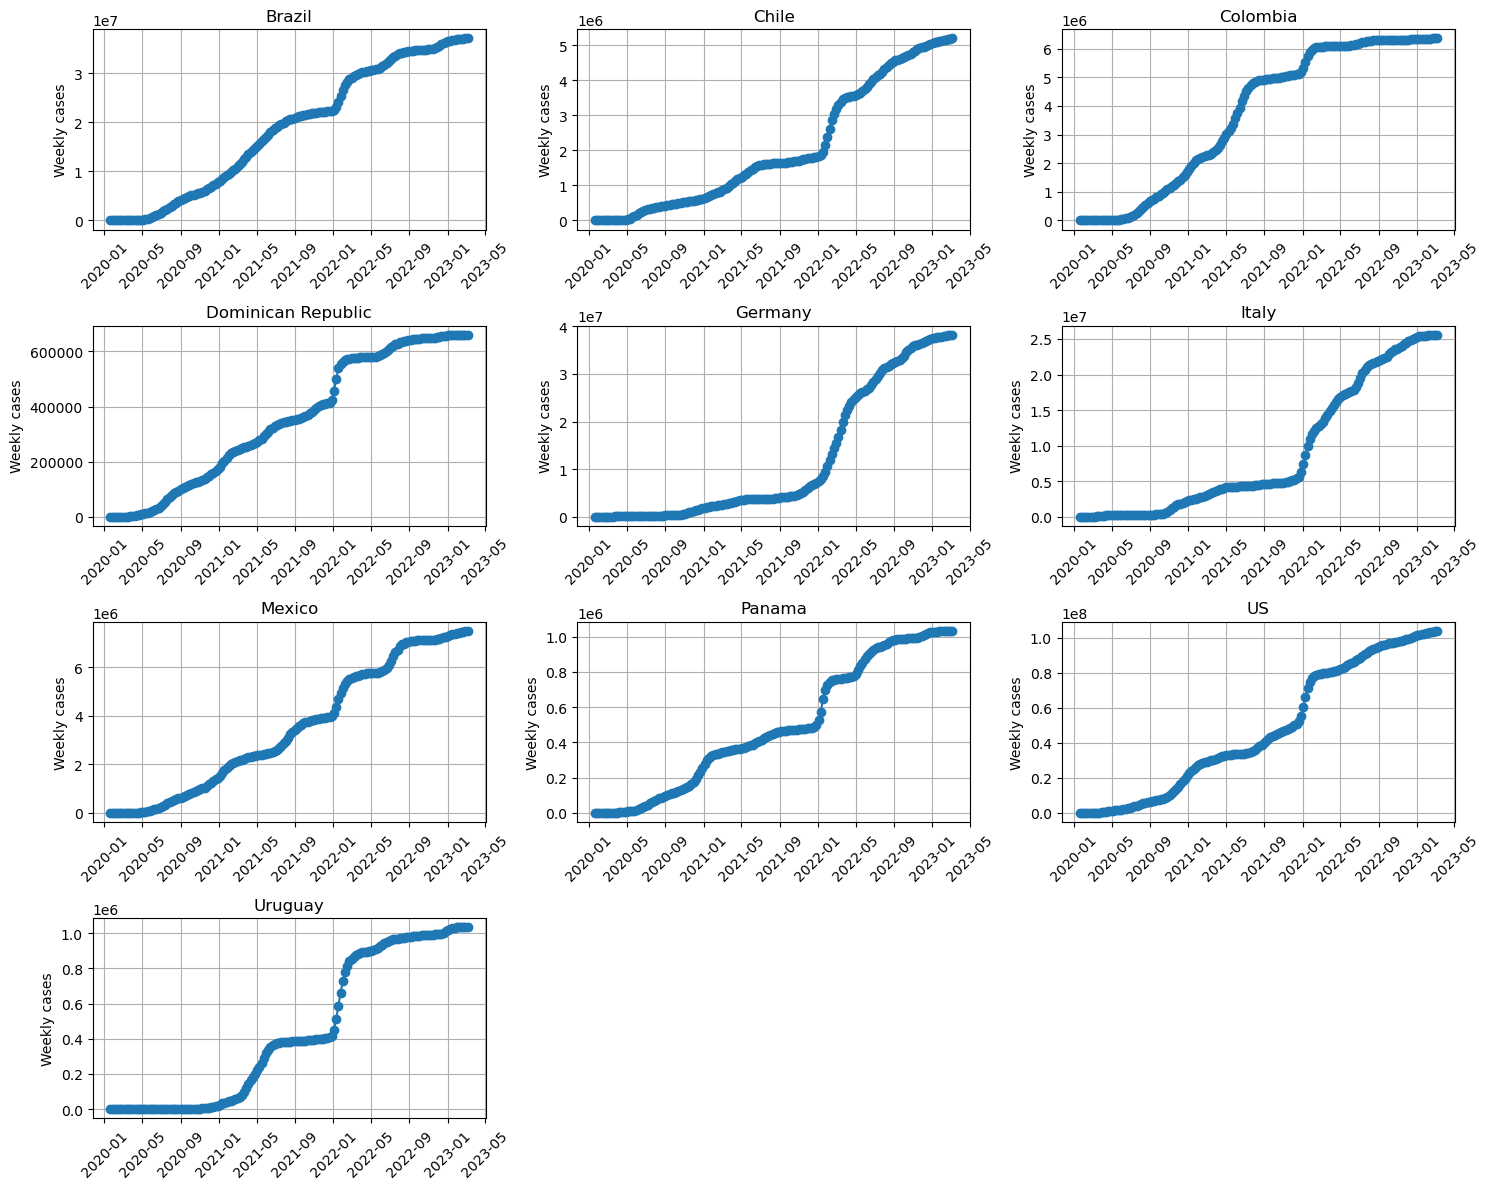

In [43]:
# 1) Prepare the DataFrame
df_covid_w['date'] = pd.to_datetime(df_covid_w['date'])
df_covid_w = df_covid_w.sort_values('date')

# Identify country columns
non_country = ['date', 'set'] if 'set' in df_covid_w.columns else ['date']
countries = [c for c in df_covid_w.columns if c not in non_country]

# 2) Set up the subplot grid
n_countries = len(countries)
ncols = 3
nrows = int(np.ceil(n_countries / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), sharex=False)
axes = axes.flatten()

# 3) Plot each country’s time series
for ax, country in zip(axes, countries):
    ax.plot(df_covid_w['date'], df_covid_w[country], marker='o', linestyle='-')
    ax.set_title(country)
    ax.set_ylabel('Weekly cases')
    ax.grid(True)
    # rotate date labels
    ax.tick_params(axis='x', rotation=45)

# 4) Remove any unused axes
for ax in axes[n_countries:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [44]:
import os

# 1) Ensure the output directory exists
output_dir = '../latex_plots'
os.makedirs(output_dir, exist_ok=True)

# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'covid_cases_by_country.pdf'),
    format='pdf',
    bbox_inches='tight'
)

### New Cases

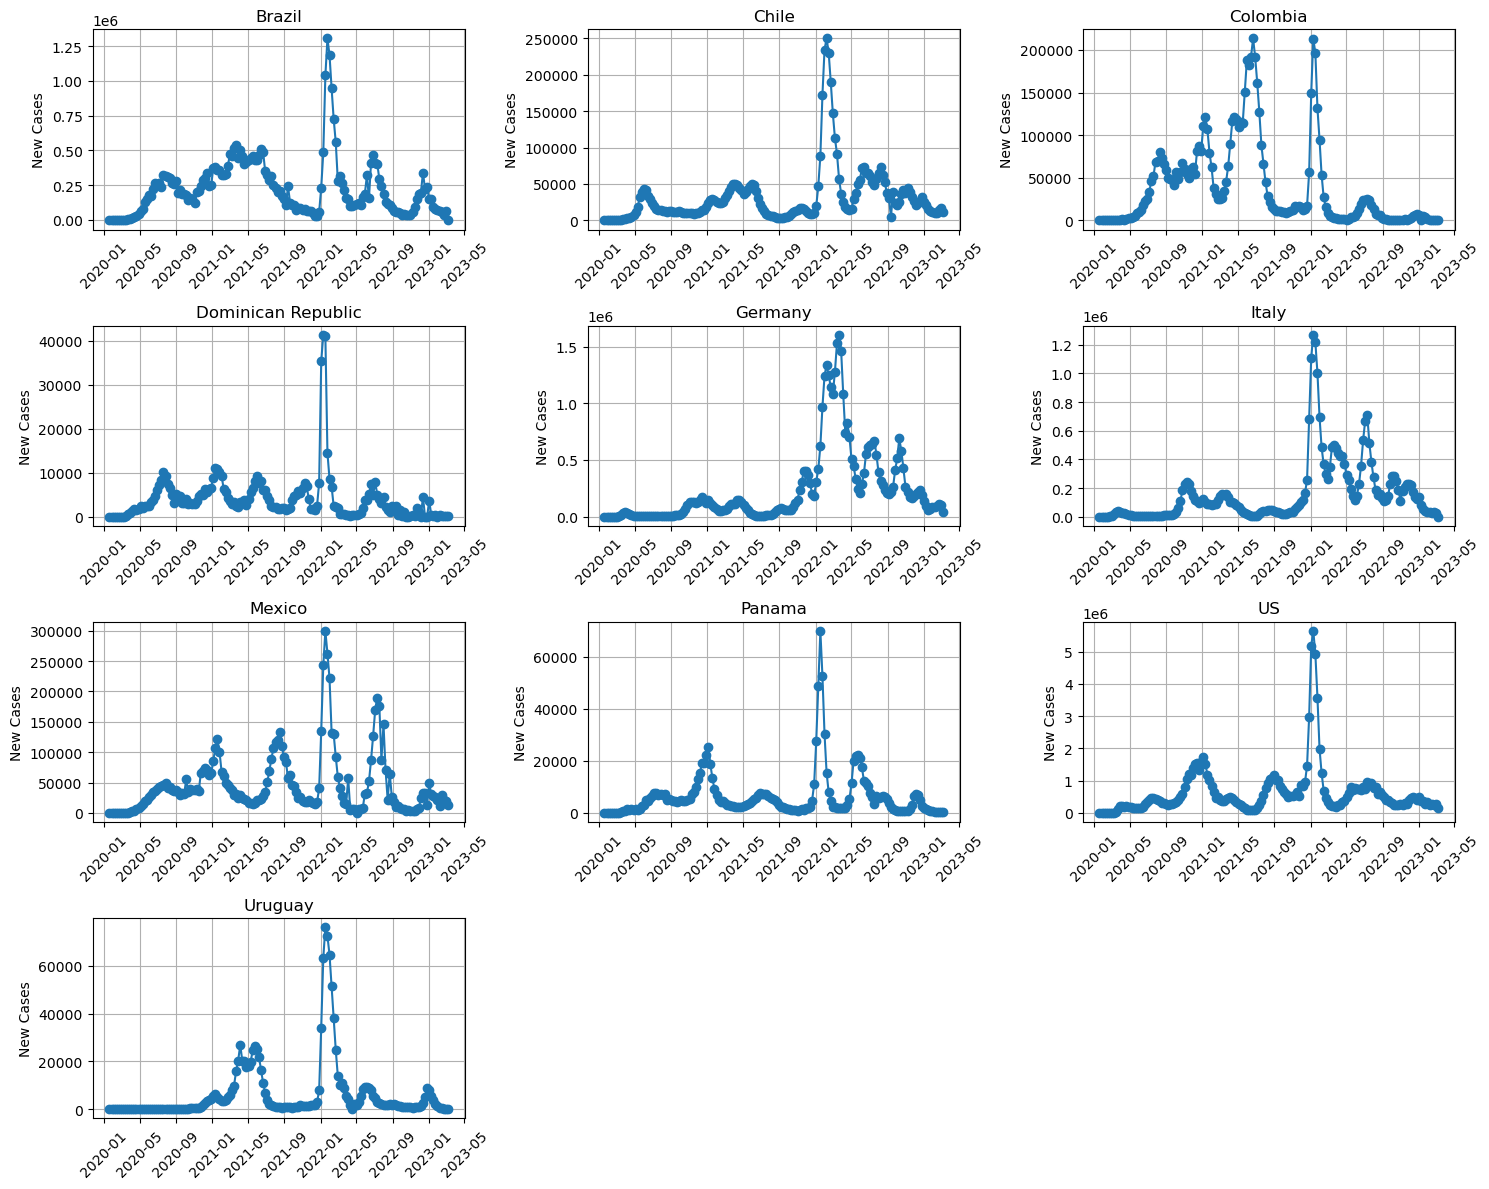

In [45]:
# 1) Convert 'date' column to datetime
df_covid['date'] = pd.to_datetime(df_covid['date'])

# 2) Pivot to wide format for plotting 'cases'
df_wide_n = df_covid.pivot(index='date', columns='country', values='new_cases')

# 3) Setup subplot grid (3 columns)
countries = df_wide_n.columns.tolist()
n_countries = len(countries)
ncols = 3
nrows = int(np.ceil(n_countries / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=False)
axes = axes.flatten()

# 4) Plot each country
for ax, country in zip(axes, countries):
    ax.plot(df_wide_n.index, df_wide_n[country], marker='o', linestyle='-')
    ax.set_title(country)
    ax.set_ylabel('New Cases')
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# 5) Remove unused subplots
for ax in axes[n_countries:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [46]:
# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'covid_new_cases_by_country.pdf'),
    format='pdf',
    bbox_inches='tight')

### Results

### Cases

In [47]:
df_epidemics.columns

Index(['date', 'dengue', 'zika', 'chik', 'var', 'dengue_split', 'zika_split',
       'chik_split', 'var_split'],
      dtype='object')

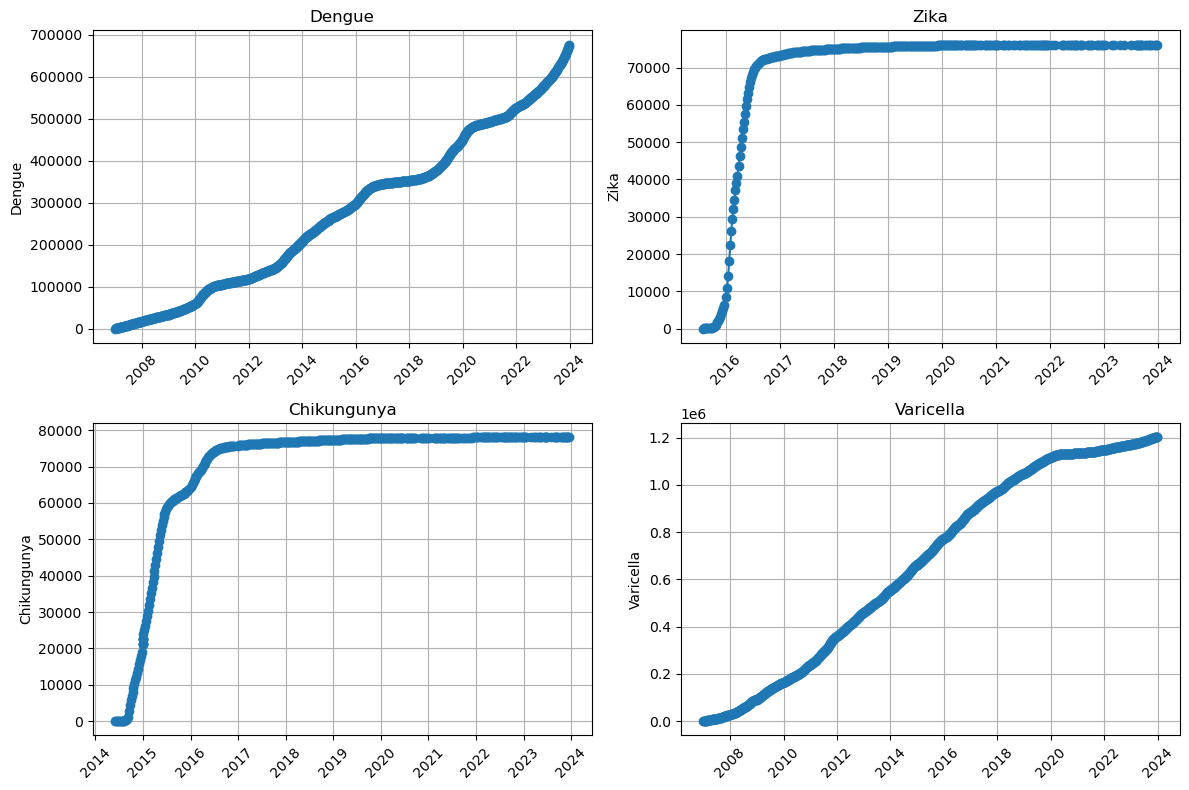

In [48]:
# 1) Make sure 'date' is datetime
df_epidemics['date'] = pd.to_datetime(df_epidemics['date'])

# 2) Specify the columns to plot and their human-readable names
variables = ['dengue', 'zika', 'chik', 'var']
names_dict = {
    'dengue': 'Dengue',
    'zika': 'Zika',
    'chik': 'Chikungunya',
    'var': 'Varicella'
}

# 3) Configure a 2×2 subplot grid
nvars = len(variables)
ncols = 2
nrows = int(np.ceil(nvars / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=False)
axes = axes.flatten()

# 4) Plot each series, dropping NaNs so each subplot has its own date range
for ax, var in zip(axes, variables):
    series = df_epidemics[['date', var]].dropna()
    ax.plot(series['date'], series[var], marker='o', linestyle='-')
    pretty_name = names_dict.get(var, var.capitalize())
    ax.set_title(pretty_name)
    ax.set_ylabel(pretty_name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# 5) Remove any unused subplots (if fewer than 4 variables)
for ax in axes[nvars:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [49]:
# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'cases_by_epidemic.pdf'),
    format='pdf',
    bbox_inches='tight')

## New Cases

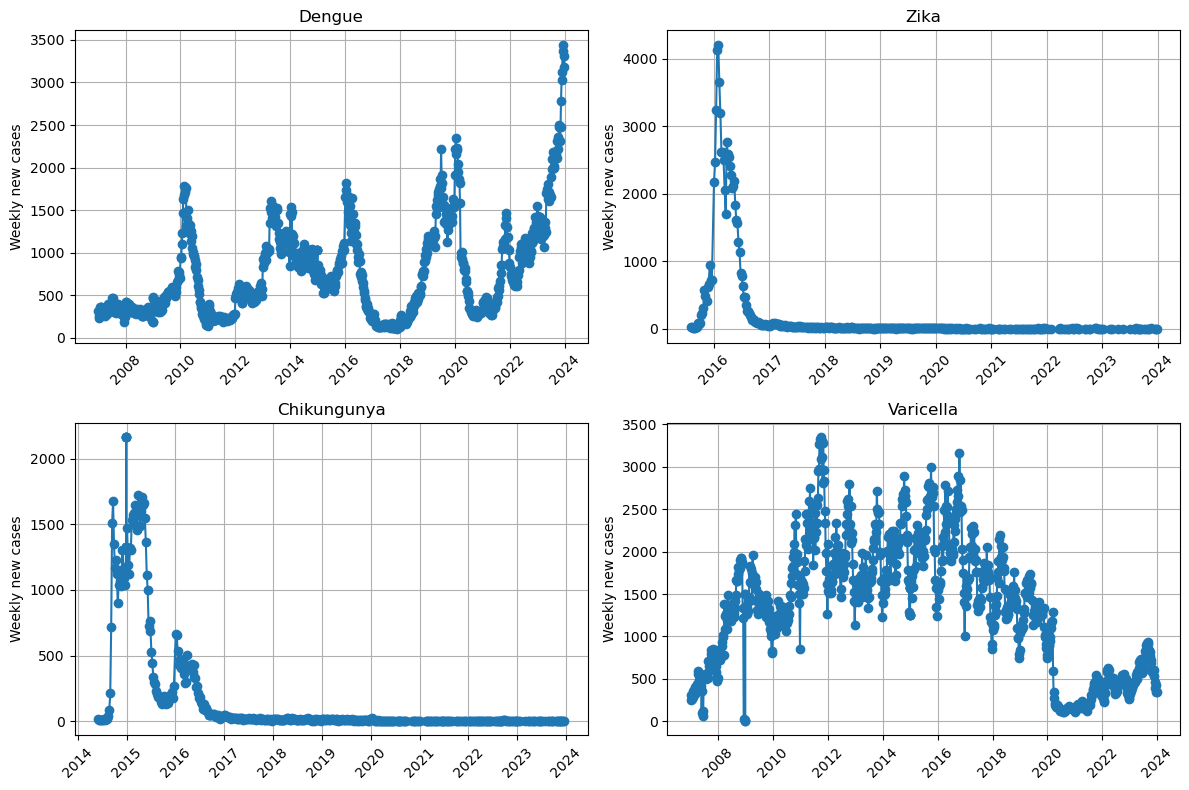

In [50]:

# -------------------------------------------------------------------
# 1.  Load raw CSVs
# -------------------------------------------------------------------
df_dengue    = pd.read_csv('../Data/silver/dengue_no_split.csv')
df_zika      = pd.read_csv('../Data/silver/zika.csv').drop(columns=['Unnamed: 0'])
df_chic      = pd.read_csv('../Data/silver/chicunguya.csv').drop(columns=['Unnamed: 0'])
df_varicela  = pd.read_csv('../Data/silver/varicela.csv')

# -------------------------------------------------------------------
# 2.  Helper to parse DATE and keep raw weekly cases
# -------------------------------------------------------------------
def prep_raw(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')
    # keep only the weekly cases column
    return df[['DATE', 'Casos']].rename(columns={'Casos': prefix})

# -------------------------------------------------------------------
# 3.  Prepare each disease frame (raw weekly cases)
# -------------------------------------------------------------------
dengue_raw   = prep_raw(df_dengue,   'dengue')
zika_raw     = prep_raw(df_zika,     'zika')
chik_raw     = prep_raw(df_chic,     'chik')
var_raw      = prep_raw(df_varicela, 'var')

# -------------------------------------------------------------------
# 4.  Outer-merge on DATE → aligns timelines, NaNs where missing
# -------------------------------------------------------------------
df_epidemics_raw = reduce(
    lambda left, right: pd.merge(left, right, on='DATE', how='outer'),
    [dengue_raw, zika_raw, chik_raw, var_raw]
).sort_values('DATE').rename(columns={'DATE': 'date'})

# -------------------------------------------------------------------
# 5.  Plot the four series in a 2×2 grid
# -------------------------------------------------------------------
variables = ['dengue', 'zika', 'chik', 'var']
names_dict = {
    'dengue': 'Dengue',
    'zika':    'Zika',
    'chik':    'Chikungunya',
    'var':     'Varicella'
}

nvars = len(variables)
ncols = 2
nrows = int(np.ceil(nvars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=False)
axes = axes.flatten()

for ax, var in zip(axes, variables):
    tmp = df_epidemics_raw[['date', var]].dropna()
    ax.plot(tmp['date'], tmp[var], marker='o', linestyle='-')
    pretty = names_dict[var]
    ax.set_title(pretty)
    ax.set_ylabel('Weekly new cases')
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# remove any unused subplots (if fewer than 4)
for ax in axes[nvars:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [51]:
# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'new_cases_by_epidemic.pdf'),
    format='pdf',
    bbox_inches='tight')